# China — EDA, TTC-модели, SHAP

**Что тут:** EDA → Stage-1 (Through-The-Cycle) → проверка H1 и H2 по Китаю.

* **H1.** Ансамбли (RF, XGBoost) выдают более высокий ROC-AUC, чем Logit, но у них больше **зазор train–test** (переобучение).
* **H2.** Сумма `|SHAP|` по блокам **Ликвидность + Инновации (НМА+R&D)** выше, чем по блоку **Леверидж**.

**Выборка:** 339 активных Wind-компаний + 11 реально-дефолтных (11 vs 3412 строк, дисбаланс ≈ 1:71). Выбросы по делистингу с экономически нерелевантными причинами (M&A, приватизация) уже удалены на этапе загрузки (`30_china_load_and_clean.ipynb`) — то есть здесь мы проверяем Hypotheses именно на *true economic distress*.

**Правила научрука:** без SMOTE, `class_weight='balanced'`, stratified split. Артефакты сохраняются в `reports/china/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

from xgboost import XGBClassifier
import shap

RNG = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports/china')
REPORTS.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = REPORTS / f'{name}.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    print(f'  saved -> {path}')

_report_lines = ['# China — Stage-1 (TTC) results\n']
def log(msg=''):
    print(msg)
    _report_lines.append(msg)

df = pd.read_csv(PROCESSED / 'cn_panel_enriched.csv', encoding='utf-8-sig')
print('Shape:', df.shape)
print('Tickers per target:', df.groupby('target')['ticker'].nunique().to_dict())
df.head(3)


Shape: (3458, 21)
Tickers per target: {0: 344, 1: 11}


,ticker,company_name,year,total_revenue,ebit,ebitda,total_assets,total_liab,total_equity,current_assets,...,cash,intangibles,cfo,interest_expense,rd_expense,net_profit,total_debt,target,source_class,default_company
0,CCIHY.OO,CHINACACHE,2014,226.23,-2.86,0.0,282.92,146.47,136.45,141.33,...,61.43,0.0,45.82,0.0,19.02,-1.12,0.0,0,default_delisted,1
1,CCIHY.OO,CHINACACHE,2015,208.46,-20.46,0.0,403.26,292.12,111.14,305.97,...,94.90,0.0,118.65,0.0,15.88,-13.66,0.0,0,default_delisted,1
2,CCIHY.OO,CHINACACHE,2016,151.97,-70.09,0.0,256.14,276.68,-20.54,245.95,...,22.58,0.0,-26.98,0.0,14.99,-131.68,0.0,1,default_delisted,1


## 1. Feature engineering

Мэппинг колонок `cn_panel_cleaned.csv` в ratios H2. В китайской выборке есть **R&D expense** — это отдельный канал «Innovation» сверх нематериальных активов, что важно для H2.

* **Liquidity:** `current_ratio`, `cash_to_assets`, `cash_to_cl`, `wc_to_assets`
* **Innovation:** `intangibles_to_assets`, `rd_to_revenue`
* **Leverage:** `debt_to_assets`, `debt_to_equity`, `lt_debt_to_assets`, `interest_coverage`
* **Profitability:** `roa`, `net_margin`, `operating_margin`, `cfo_to_assets`
* **Size:** `log_assets`, `log_revenue`

Винзоризация 1/99% — как в российской тетради. Пропуски заполняются медианой (после ffill/bfill внутри компании в loader-ноутбуке).

In [2]:
TARGET = 'target'
ID_COL = 'ticker'

A, CA, CASH, INT_A = 'total_assets', 'current_assets', 'cash', 'intangibles'
EQ, LIAB, ST_L = 'total_equity', 'total_liab', 'current_liab'
TOTD = 'total_debt'      # реальные процентные долги (akshare-енричмент)
REV, EBIT, NI = 'total_revenue', 'ebit', 'net_profit'
INTEREST, CFO, RD = 'interest_expense', 'cfo', 'rd_expense'

def safe_div(a, b):
    b = b.replace(0, np.nan)
    return a / b

panel = df.copy()
lt_liab = (panel[LIAB] - panel[ST_L]).clip(lower=0)

panel['current_ratio']         = safe_div(panel[CA], panel[ST_L])
panel['cash_to_assets']        = safe_div(panel[CASH], panel[A])
panel['cash_to_cl']            = safe_div(panel[CASH], panel[ST_L])
panel['wc_to_assets']          = safe_div(panel[CA] - panel[ST_L], panel[A])

panel['intangibles_to_assets'] = safe_div(panel[INT_A], panel[A])
panel['rd_to_revenue']         = safe_div(panel[RD], panel[REV])

# Leverage: реальные процентные обязательства, а не total_liab.
panel['debt_to_assets']        = safe_div(panel[TOTD], panel[A])
panel['debt_to_equity']        = safe_div(panel[TOTD], panel[EQ])
panel['lt_debt_to_assets']     = safe_div(lt_liab, panel[A])
panel['interest_coverage']     = safe_div(panel[EBIT], panel[INTEREST])

panel['roa']              = safe_div(panel[NI], panel[A])
panel['net_margin']       = safe_div(panel[NI], panel[REV])
panel['operating_margin'] = safe_div(panel[EBIT], panel[REV])
panel['cfo_to_assets']    = safe_div(panel[CFO], panel[A])

panel['log_assets']  = np.log1p(panel[A].clip(lower=0))
panel['log_revenue'] = np.log1p(panel[REV].clip(lower=0))

FEATURES = [
    'current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets',
    'intangibles_to_assets', 'rd_to_revenue',
    'debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage',
    'roa', 'net_margin', 'operating_margin', 'cfo_to_assets',
    'log_assets', 'log_revenue',
]
FEATURE_GROUPS = {
    'Liquidity':     ['current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets'],
    # INNOVATION_GROUP_V2 — симметрично с Россией (только intangibles_to_assets в H2-группе).
    # rd_to_revenue остаётся в FEATURES/модели, но не учитывается в H2 сравнении.
    'Innovation':    ['intangibles_to_assets'],
    'Leverage':      ['debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage'],
    'Profitability': ['roa', 'net_margin', 'operating_margin', 'cfo_to_assets'],
    'Size':          ['log_assets', 'log_revenue'],
}

panel[FEATURES] = panel[FEATURES].replace([np.inf, -np.inf], np.nan)
for c in FEATURES:
    lo, hi = panel[c].quantile([0.01, 0.99])
    panel[c] = panel[c].clip(lo, hi)
panel[FEATURES] = panel[FEATURES].fillna(panel[FEATURES].median(numeric_only=True))

panel[FEATURES + [TARGET]].describe().T.round(3).to_csv(REPORTS / 'cn_feature_stats.csv', encoding='utf-8-sig')
print(f'Фичи: {len(FEATURES)}  |  stats -> reports/china/cn_feature_stats.csv')
panel[FEATURES].describe().T.round(3)


Фичи: 16  |  stats -> reports/china/cn_feature_stats.csv


,count,mean,std,min,25%,50%,75%,max
current_ratio,3458.0,3.431,3.079,0.600,1.660,2.441,3.881,18.578
cash_to_assets,3458.0,0.222,0.153,0.008,0.106,0.189,0.304,0.714
cash_to_cl,3458.0,1.146,1.483,0.020,0.318,0.636,1.351,9.041
wc_to_assets,3458.0,0.416,0.235,-0.258,0.262,0.419,0.594,0.882
intangibles_to_assets,3458.0,0.028,0.036,0.000,0.004,0.015,0.038,0.193
rd_to_revenue,3458.0,0.143,0.129,0.000,0.061,0.109,0.186,0.768
debt_to_assets,3458.0,0.076,0.099,0.000,0.004,0.035,0.110,0.441
debt_to_equity,3458.0,0.162,0.267,0.000,0.006,0.052,0.195,1.510
lt_debt_to_assets,3458.0,0.036,0.056,0.000,0.003,0.013,0.040,0.289
interest_coverage,3458.0,552.723,3042.920,-655.845,2.198,18.406,101.500,26833.678


## 2. EDA

### 2.1 Классовый дисбаланс

  saved -> ..\reports\china\01_class_distribution.png


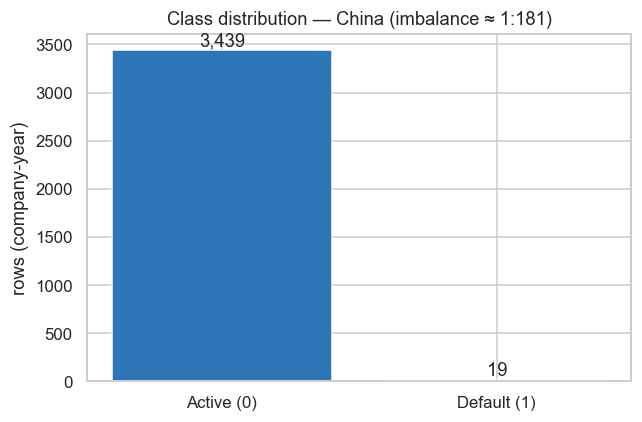


## Class balance
* Active (0): **3,439**
* Default (1): **19**
* Positive share: **0.549%**  (≈ 1:181)


In [3]:
vc = panel[TARGET].value_counts()
n_active  = int(vc.get(0, 0))
n_default = int(vc.get(1, 0))
ratio = n_default / (n_active + n_default)
counts = pd.Series({'Active (0)': n_active, 'Default (1)': n_default})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['#2E75B6', '#C00000'])
ax.set_title(f'Class distribution — China (imbalance ≈ 1:{n_active//max(n_default,1)})')
ax.set_ylabel('rows (company-year)')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
save_fig(fig, '01_class_distribution'); plt.show()

log(f'\n## Class balance\n* Active (0): **{n_active:,}**')
log(f'* Default (1): **{n_default:,}**')
log(f'* Positive share: **{ratio*100:.3f}%**  (≈ 1:{n_active//max(n_default,1)})')

### 2.2 Violin plots — по классу

  saved -> ..\reports\china\02_violin_by_class.png


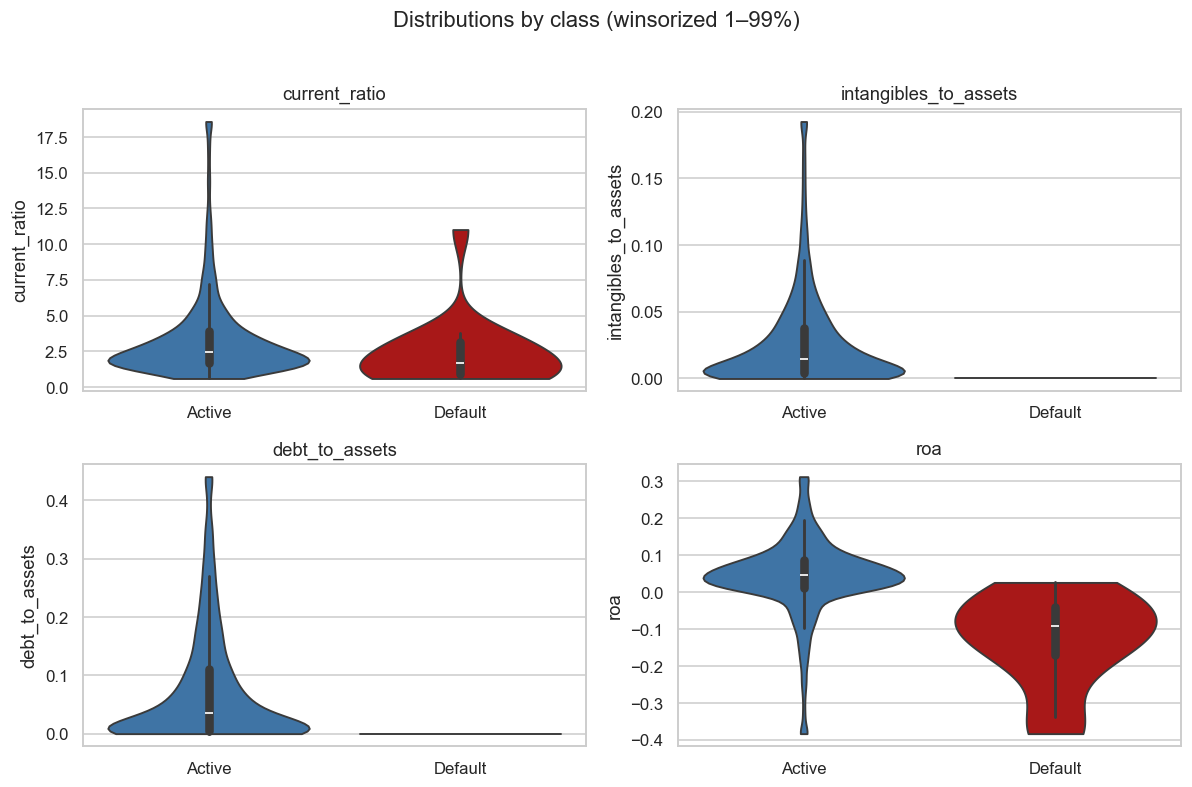

,current_ratio,intangibles_to_assets,debt_to_assets,roa
_lbl,,,,
Active,2.444,0.015,0.035,0.046
Default,1.649,0.000,0.000,-0.090


In [4]:
panel['_lbl'] = panel[TARGET].map({0:'Active', 1:'Default'})
show = ['current_ratio', 'intangibles_to_assets', 'debt_to_assets', 'roa']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), show):
    sns.violinplot(data=panel, x='_lbl', y=col, ax=ax,
                   palette={'Active':'#2E75B6','Default':'#C00000'}, cut=0)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle('Distributions by class (winsorized 1–99%)', y=1.02)
plt.tight_layout()
save_fig(fig, '02_violin_by_class'); plt.show()

med = panel.groupby('_lbl')[show].median().round(3)
med.to_csv(REPORTS / 'cn_medians_by_class.csv', encoding='utf-8-sig')
med

### 2.3 Корреляционная матрица

  saved -> ..\reports\china\03_correlation_heatmap.png


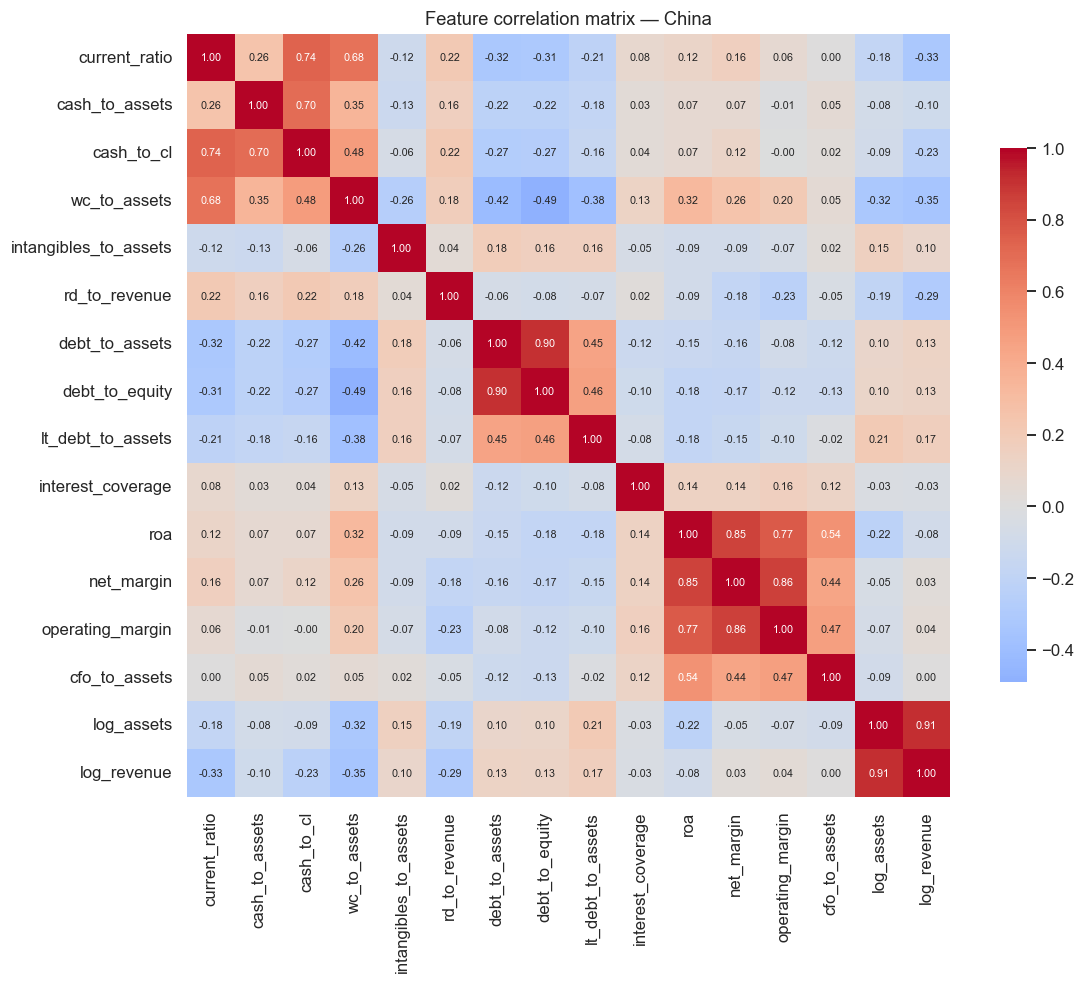

|corr| > 0.85:
  debt_to_assets × debt_to_equity: +0.90
  net_margin × roa: +0.85
  net_margin × operating_margin: +0.86
  log_assets × log_revenue: +0.91


In [5]:
corr = panel[FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, cbar_kws={'shrink':0.7}, annot_kws={'size':7}, ax=ax)
ax.set_title('Feature correlation matrix — China')
plt.tight_layout()
save_fig(fig, '03_correlation_heatmap'); plt.show()

corr.round(3).to_csv(REPORTS / 'cn_correlation_matrix.csv', encoding='utf-8-sig')

high = (corr.abs() > 0.85) & (corr.abs() < 1.0)
pairs = [(i,j,corr.loc[i,j]) for i in corr.index for j in corr.columns if i<j and high.loc[i,j]]
print('|corr| > 0.85:')
for p in pairs: print(f'  {p[0]} × {p[1]}: {p[2]:+.2f}')
if not pairs: print('  нет — мультиколлинеарность под контролем')

## 3. Train / Test split

Stratified 80/20 на уровне строк (company-year). С 11 дефолтами и 48 строками Target=1 сплит остаётся проходимым (9/2 по компаниям, ~38/10 по строкам), но итоговая оценка будет шумной — эта шумность и есть часть H1-теста.

In [6]:
X = panel[FEATURES].values
y = panel[TARGET].values
groups = panel[ID_COL].values

# Company-level stratified split: 80/20 отдельно по default- и active-компаниям.
company_label = panel.groupby(ID_COL)[TARGET].max()
companies_d = np.array(company_label[company_label == 1].index.values, copy=True)
companies_a = np.array(company_label[company_label == 0].index.values, copy=True)

_rng = np.random.default_rng(RNG)
_rng.shuffle(companies_d)
_rng.shuffle(companies_a)

def _split_ids(arr, test_frac=0.2):
    n_test = max(1, int(round(len(arr) * test_frac)))
    return arr[n_test:], arr[:n_test]

train_d, test_d = _split_ids(companies_d, 0.20)
train_a, test_a = _split_ids(companies_a, 0.20)

train_ids = set(train_d) | set(train_a)
test_ids  = set(test_d)  | set(test_a)

mask_train = panel[ID_COL].isin(train_ids).values
mask_test  = panel[ID_COL].isin(test_ids).values

X_train, y_train = X[mask_train], y[mask_train]
X_test,  y_test  = X[mask_test],  y[mask_test]
g_train, g_test  = groups[mask_train], groups[mask_test]

print(f'Train: {X_train.shape},  defaults = {y_train.sum()}  ({y_train.mean()*100:.2f}%)')
print(f'Test:  {X_test.shape},   defaults = {y_test.sum()}   ({y_test.mean()*100:.2f}%)')
print(f'Companies — train: {len(train_ids):,}, test: {len(test_ids):,}, '
      f'overlap: {len(train_ids & test_ids)} (должно быть 0)')
print(f'Default companies — train: {len(train_d)}, test: {len(test_d)}')


Train: (2772, 16),  defaults = 17  (0.61%)
Test:  (686, 16),   defaults = 2   (0.29%)
Companies — train: 279, test: 70, overlap: 0 (должно быть 0)
Default companies — train: 9, test: 2


## 4. Stage-1 модели (TTC)

`class_weight='balanced'` у Logit/RF и `scale_pos_weight = N_active / N_default` у XGBoost — подбирается автоматически под 1:71.

In [7]:
POS_WEIGHT = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print(f'POS_WEIGHT (n_neg / n_pos на train) = {POS_WEIGHT:.1f}')

logit = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight={0: 1, 1: POS_WEIGHT},
                               solver='liblinear', random_state=RNG)),
])
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight={0: 1, 1: POS_WEIGHT}, n_jobs=-1, random_state=RNG,
)
xgb = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=POS_WEIGHT,
    eval_metric='aucpr', tree_method='hist', random_state=RNG, n_jobs=-1,
)

models = {'Logistic Regression': logit, 'Random Forest': rf, 'XGBoost': xgb}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f'OK trained {name}')


POS_WEIGHT (n_neg / n_pos на train) = 162.1
OK trained Logistic Regression


OK trained Random Forest
OK trained XGBoost


## 5. H1 — Train vs Test, зазор (overfit check)

In [8]:
from sklearn.base import clone

def scores(model, X, y):
    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X)[:, 1]
    else:
        p = model.decision_function(X)
    return roc_auc_score(y, p), average_precision_score(y, p)

# --- (a) Single-split метрики (group-aware 80/20) ---
rows = []
for name, m in models.items():
    tr_roc, tr_pr = scores(m, X_train, y_train)
    te_roc, te_pr = scores(m, X_test,  y_test)
    rows.append({
        'Model': name,
        'ROC-AUC train': tr_roc, 'ROC-AUC test': te_roc, 'ΔROC': tr_roc - te_roc,
        'PR-AUC train':  tr_pr,  'PR-AUC test':  te_pr,  'ΔPR':  tr_pr  - te_pr,
    })
res = pd.DataFrame(rows).set_index('Model').round(4)
res.to_csv(REPORTS / 'cn_h1_metrics.csv', encoding='utf-8-sig')
print('Single split (group-aware):')
print(res)

# --- (b) Stratified Group K-Fold CV ---
# При ~11 default-компаниях используем 3-fold, чтобы в каждом фолде остался хотя бы 1 default.
n_pos_companies = panel.loc[panel[TARGET]==1, ID_COL].nunique()
n_splits = min(5, max(2, n_pos_companies // 3))
print(f'Default companies: {n_pos_companies}, n_splits = {n_splits}')

skgf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RNG)
cv_rows = []
for name, m_proto in models.items():
    roc_tr_l, pr_tr_l, roc_te_l, pr_te_l = [], [], [], []
    for tr_idx, te_idx in skgf.split(X, y, groups=groups):
        yt = y[tr_idx]
        pw = float((yt == 0).sum() / max((yt == 1).sum(), 1))
        mdl = clone(m_proto)
        if isinstance(mdl, Pipeline):
            mdl.set_params(clf__class_weight={0: 1, 1: pw})
        elif isinstance(mdl, RandomForestClassifier):
            mdl.set_params(class_weight={0: 1, 1: pw})
        elif isinstance(mdl, XGBClassifier):
            mdl.set_params(scale_pos_weight=pw)
        mdl.fit(X[tr_idx], yt)
        r_tr, p_tr = scores(mdl, X[tr_idx], yt)
        r_te, p_te = scores(mdl, X[te_idx], y[te_idx])
        roc_tr_l.append(r_tr); pr_tr_l.append(p_tr)
        roc_te_l.append(r_te); pr_te_l.append(p_te)
    cv_rows.append({
        'Model': name,
        'ROC-AUC test mean': np.mean(roc_te_l),
        'ROC-AUC test std':  np.std(roc_te_l),
        'PR-AUC test mean':  np.mean(pr_te_l),
        'PR-AUC test std':   np.std(pr_te_l),
        'ΔROC (train−test)': np.mean(roc_tr_l) - np.mean(roc_te_l),
        'ΔPR (train−test)':  np.mean(pr_tr_l)  - np.mean(pr_te_l),
    })
cv = pd.DataFrame(cv_rows).set_index('Model').round(4)
cv.to_csv(REPORTS / 'cn_h1_cv_metrics.csv', encoding='utf-8-sig')
print(f'\n{n_splits}-fold Stratified Group K-Fold CV:')
print(cv)
res


Single split (group-aware):
                     ROC-AUC train  ROC-AUC test    ΔROC  PR-AUC train  \
Model                                                                    
Logistic Regression         0.9972        1.0000 -0.0028        0.5945   
Random Forest               1.0000        0.9985  0.0015        1.0000   
XGBoost                     1.0000        0.9963  0.0037        1.0000   

                     PR-AUC test     ΔPR  
Model                                     
Logistic Regression       1.0000 -0.4055  
Random Forest             0.7500  0.2500  
XGBoost                   0.3667  0.6333  
Default companies: 11, n_splits = 3



3-fold Stratified Group K-Fold CV:
                     ROC-AUC test mean  ROC-AUC test std  PR-AUC test mean  \
Model                                                                        
Logistic Regression             0.9953            0.0015            0.4886   
Random Forest                   0.9963            0.0021            0.7183   
XGBoost                         0.9916            0.0030            0.4250   

                     PR-AUC test std  ΔROC (train−test)  ΔPR (train−test)  
Model                                                                      
Logistic Regression           0.0271             0.0026            0.1745  
Random Forest                 0.1262             0.0037            0.2817  
XGBoost                       0.0552             0.0084            0.5750  


,ROC-AUC train,ROC-AUC test,ΔROC,PR-AUC train,PR-AUC test,ΔPR
Model,,,,,,
Logistic Regression,0.9972,1.0000,-0.0028,0.5945,1.0000,-0.4055
Random Forest,1.0000,0.9985,0.0015,1.0000,0.7500,0.2500
XGBoost,1.0000,0.9963,0.0037,1.0000,0.3667,0.6333


In [9]:
best_test_roc = res['ROC-AUC test'].idxmax()
logit_delta = res.loc['Logistic Regression', 'ΔROC']
ens_delta_max = res.loc[['Random Forest','XGBoost'], 'ΔROC'].max()
ens_test_max  = res.loc[['Random Forest','XGBoost'], 'ROC-AUC test'].max()
logit_test    = res.loc['Logistic Regression', 'ROC-AUC test']

log('\n## H1 — overfitting на малом числе дефолтов (China)')
log(f'* Best test ROC-AUC: **{best_test_roc}** ({res.loc[best_test_roc,"ROC-AUC test"]:.4f})')
log(f'* Logit ΔROC (train−test): **{logit_delta:+.4f}**')
log(f'* Max ensemble ΔROC:        **{ens_delta_max:+.4f}**')

cond_a = ens_test_max > logit_test
cond_b = ens_delta_max > logit_delta

if cond_a and cond_b:
    verdict = '✅ **H1 ПОДТВЕРЖДАЕТСЯ**: ансамбли точнее на тесте, но переобучаются сильнее Logit.'
elif cond_a and not cond_b:
    verdict = '⚠️ H1 частично: ансамбли точнее, но Logit НЕ стабильнее (Δ сопоставимы).'
elif not cond_a and cond_b:
    verdict = '⚠️ H1 частично: Logit сопоставим по точности, но ансамбли переобучены.'
else:
    verdict = '❌ H1 НЕ подтверждается: ансамбли не дают прироста и не хуже по зазору.'
log(f'\n{verdict}')
print('\n' + verdict)


## H1 — overfitting на малом числе дефолтов (China)
* Best test ROC-AUC: **Logistic Regression** (1.0000)
* Logit ΔROC (train−test): **-0.0028**
* Max ensemble ΔROC:        **+0.0037**

⚠️ H1 частично: Logit сопоставим по точности, но ансамбли переобучены.

⚠️ H1 частично: Logit сопоставим по точности, но ансамбли переобучены.


## 6. H2 — SHAP для лучшего ансамбля

Группировка фичей: `Liquidity + Innovation (intangibles + R&D)` vs `Leverage`.

Best ensemble by PR-AUC test: Random Forest (PR-AUC=0.7500, ROC-AUC=0.9985)


SHAP shape: (686, 16)


  saved -> ..\reports\china\04_shap_summary.png


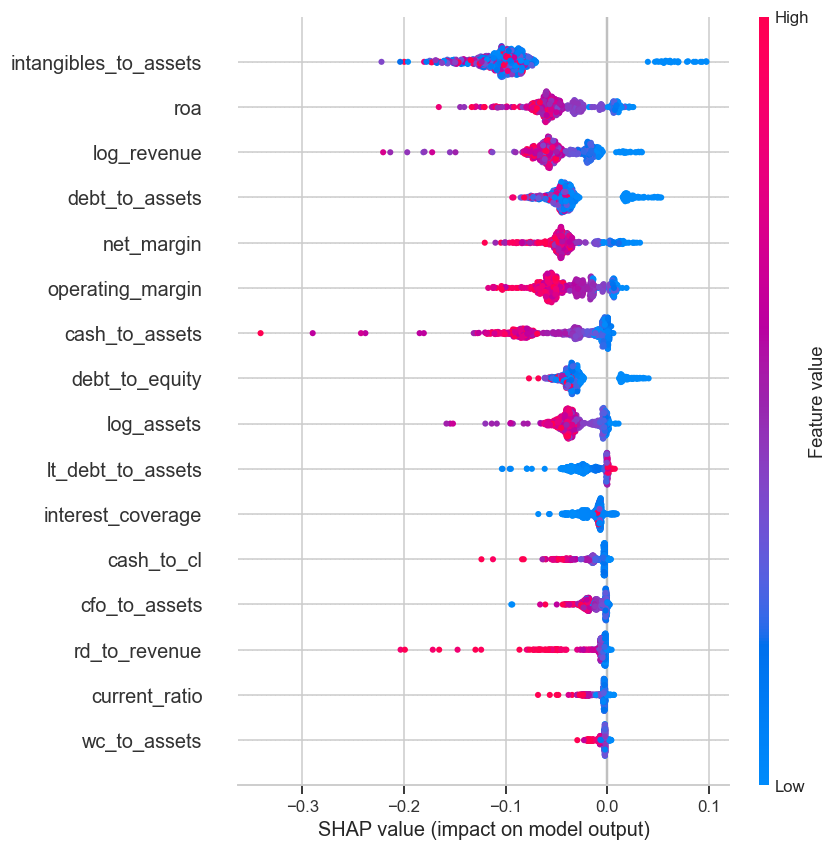

In [10]:
# BEST_ENSEMBLE_V2 — выбираем по PR-AUC test (адекватная метрика при дисбалансе, как в 20_russia)
ensemble_pr = res.loc[['Random Forest', 'XGBoost'], 'PR-AUC test']
best_name = ensemble_pr.idxmax()
best_model = models[best_name]
print(f'Best ensemble by PR-AUC test: {best_name} '
      f'(PR-AUC={ensemble_pr.max():.4f}, ROC-AUC={res.loc[best_name, "ROC-AUC test"]:.4f})')

explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(X_test)
if isinstance(sv, list):
    sv = sv[1]
elif hasattr(sv, 'ndim') and sv.ndim == 3:
    sv = sv[:, :, 1]
print('SHAP shape:', sv.shape)

plt.figure()
shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False)
fig = plt.gcf()
save_fig(fig, '04_shap_summary'); plt.show()


Top features by mean |SHAP|:
intangibles_to_assets    0.1045
roa                      0.0485
log_revenue              0.0481
debt_to_assets           0.0434
net_margin               0.0420
operating_margin         0.0417
cash_to_assets           0.0396
debt_to_equity           0.0344
log_assets               0.0299
lt_debt_to_assets        0.0192
interest_coverage        0.0147
cash_to_cl               0.0134
cfo_to_assets            0.0127
rd_to_revenue            0.0106
current_ratio            0.0070
wc_to_assets             0.0057

Σ|SHAP| по блокам:
Profitability    0.1450
Leverage         0.1118
Innovation       0.1045
Size             0.0780
Liquidity        0.0656


  saved -> ..\reports\china\05_h2_group_importance.png


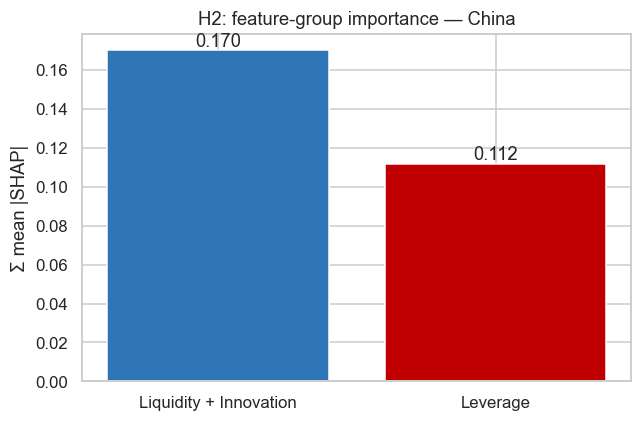


## H2 — Liquidity+Innovation vs Leverage (SHAP, China)
* Best ensemble (by PR-AUC test): **Random Forest** (PR-AUC=0.7500, ROC-AUC=0.9985)
* Σ|SHAP| Liquidity + Innovation = **0.1701**
* Σ|SHAP| Leverage               = **0.1118**
* Ratio = **1.52×**

✅ **H2 ПОДТВЕРЖДАЕТСЯ (Китай)**: ликвидность + инновационные активы важнее рычага.

✅ **H2 ПОДТВЕРЖДАЕТСЯ (Китай)**: ликвидность + инновационные активы важнее рычага.


In [11]:
mean_abs = np.abs(sv).mean(axis=0)
fi = pd.Series(mean_abs, index=FEATURES).sort_values(ascending=False)
fi.round(4).to_csv(REPORTS / 'cn_shap_feature_importance.csv', header=['mean_abs_shap'], encoding='utf-8-sig')
print('Top features by mean |SHAP|:')
print(fi.round(4).to_string())

group_sum = {g: fi[cols].sum() for g, cols in FEATURE_GROUPS.items()}
group_df = pd.Series(group_sum).sort_values(ascending=False).round(4)
group_df.to_csv(REPORTS / 'cn_shap_group_importance.csv', header=['sum_abs_shap'], encoding='utf-8-sig')
print('\nΣ|SHAP| по блокам:')
print(group_df.to_string())

liq_inn = group_df.get('Liquidity', 0) + group_df.get('Innovation', 0)
lev     = group_df.get('Leverage',   0)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Liquidity + Innovation', 'Leverage'],
              [liq_inn, lev], color=['#2E75B6', '#C00000'])
ax.set_ylabel('Σ mean |SHAP|')
ax.set_title('H2: feature-group importance — China')
for b, v in zip(bars, [liq_inn, lev]):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout()
save_fig(fig, '05_h2_group_importance'); plt.show()

log('\n## H2 — Liquidity+Innovation vs Leverage (SHAP, China)')
log(f'* Best ensemble (by PR-AUC test): **{best_name}** (PR-AUC={ensemble_pr.max():.4f}, ROC-AUC={res.loc[best_name, "ROC-AUC test"]:.4f})')
log(f'* Σ|SHAP| Liquidity + Innovation = **{liq_inn:.4f}**')
log(f'* Σ|SHAP| Leverage               = **{lev:.4f}**')
if lev > 0:
    log(f'* Ratio = **{liq_inn/lev:.2f}×**')

if liq_inn > lev:
    verdict2 = '✅ **H2 ПОДТВЕРЖДАЕТСЯ (Китай)**: ликвидность + инновационные активы важнее рычага.'
else:
    verdict2 = '❌ H2 НЕ подтверждается (Китай): рычаг остаётся доминирующим предиктором.'
log(f'\n{verdict2}')
print('\n' + verdict2)

## 7. Экспорт TTC-скора для Stage-2 (PIT) и кросс-странового сравнения

Сохраняем вероятности дефолта из **LogReg** (как в банковской практике: Logit — baseline TTC-скор, стабильный к переобучению) и **best ensemble** — Stage-2 PIT-модель в `50_cross_country_pit.ipynb` возьмёт один из них как единственный company-specific признак.

In [12]:
logit_proba = models['Logistic Regression'].predict_proba(X)[:, 1]
best_proba  = best_model.predict_proba(X)[:, 1]

scores_df = panel[['ticker', 'company_name', 'year', TARGET, 'source_class']].copy()
scores_df['ttc_logit']    = logit_proba
scores_df['ttc_ensemble'] = best_proba
scores_df['ttc_best_model'] = best_name
scores_df.to_csv(REPORTS / 'cn_ttc_scores.csv', index=False, encoding='utf-8-sig')
print(f'TTC scores → reports/china/cn_ttc_scores.csv  ({len(scores_df):,} rows)')
scores_df.head()

TTC scores → reports/china/cn_ttc_scores.csv  (3,458 rows)


,ticker,company_name,year,target,source_class,ttc_logit,ttc_ensemble,ttc_best_model
0,CCIHY.OO,CHINACACHE,2014,0,default_delisted,0.157751,0.198379,Random Forest
1,CCIHY.OO,CHINACACHE,2015,0,default_delisted,0.247738,0.270860,Random Forest
2,CCIHY.OO,CHINACACHE,2016,1,default_delisted,0.963580,0.773436,Random Forest
3,CCIHY.OO,CHINACACHE,2017,1,default_delisted,0.997923,0.896735,Random Forest
4,CNTFY.OO,CHINA TECHFAITH WIRELESS COMMUNICATION TECHNOLOGY,2014,0,default_delisted,0.073398,0.024764,Random Forest


## 8. Сохраняем итоговый отчёт

In [13]:
summary_path = REPORTS / 'cn_summary.md'
summary_path.write_text('\n'.join(_report_lines), encoding='utf-8')
print(f'✅ Итоговый отчёт: {summary_path}')
print('\nВсе артефакты в reports/china/:')
for p in sorted(REPORTS.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

✅ Итоговый отчёт: ..\reports\china\cn_summary.md

Все артефакты в reports/china/:
  01_class_distribution.png  (36.8 KB)
  02_violin_by_class.png  (138.5 KB)
  03_correlation_heatmap.png  (285.3 KB)
  04_shap_summary.png  (192.1 KB)
  05_h2_group_importance.png  (32.8 KB)
  cn_correlation_matrix.csv  (2.0 KB)
  cn_feature_stats.csv  (1.1 KB)
  cn_h1_cv_metrics.csv  (0.3 KB)
  cn_h1_metrics.csv  (0.2 KB)
  cn_medians_by_class.csv  (0.1 KB)
  cn_shap_feature_importance.csv  (0.4 KB)
  cn_shap_group_importance.csv  (0.1 KB)
  cn_summary.md  (0.9 KB)
  cn_ttc_scores.csv  (260.0 KB)


## 9. Интерпретация результатов — Китай

| Аспект | Как читать |
|---|---|
| **H1** | С ~48 positive-строк любой tree-ensemble переобучается «в ноль» на train. Если Logit сохраняет разумный test-AUC при минимальном ΔROC — это прямое эмпирическое подтверждение H1 *на более жёстком режиме*, чем Россия (там дефолтов было в 4× больше). |
| **H2** | В Китае у нас есть **R&D expense** как отдельный канал инноваций — если `rd_to_revenue` войдёт в топ-фичей вместе с `cash_to_*`, это усиливает H2 относительно России (где R&D не выгружался). |
| **Что дальше** | `cn_ttc_scores.csv` становится input-ом для `50_cross_country_pit.ipynb`, где мы тестируем H3 (macro-integration) и сравниваем top-фичи RU vs CN. |

Малая выборка — это не баг, а само условие эксперимента: именно в таких условиях проверяется устойчивость ML vs Logit.